<a href="https://colab.research.google.com/github/Ashwell-CG/Fake-News-Detection-Using-NLP/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("rahulogoel/isot-fake-news-dataset")

Using Colab cache for faster access to the 'isot-fake-news-dataset' dataset.


In [2]:
print(path)

/kaggle/input/isot-fake-news-dataset


In [3]:
import string
import nltk

# Download required data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function
def preprocess_text(text):
    if text is None:
        return ""

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [4]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
import kagglehub
path = kagglehub.dataset_download("rahulogoel/isot-fake-news-dataset")
import pandas as pd
import string
import nltk

# Download required data (these are idempotent)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to resolve LookupError

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function definition for preprocess_text
def preprocess_text(text):
    if text is None:
        return ""

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for token in tokens if (word:= token.strip()) and word not in stop_words] # Modified to handle potential empty strings after stripping

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

true_df = pd.read_csv(path + "/News_Dataset/True.csv")
fake_df = pd.read_csv(path + "/News_Dataset/Fake.csv")

# Labels
true_df['label'] = 1
fake_df['label'] = 0

# Combine
df = pd.concat([true_df, fake_df], ignore_index=True);

# Create content
df['content'] = df['title'] + " " + df["text"]

# Remove nulls
df.dropna(inplace=True)

# Preprocess
df['clean_text'] = df['content'].apply(preprocess_text)

df.head()

Using Colab cache for faster access to the 'isot-fake-news-dataset' dataset.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,title,text,subject,date,label,content,clean_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,"As U.S. budget fight looms, Republicans flip t...",u budget fight loom republican flip fiscal scr...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,U.S. military to accept transgender recruits o...,u military accept transgender recruit monday p...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,Senior U.S. Republican senator: 'Let Mr. Muell...,senior u republican senator let mr mueller job...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1,FBI Russia probe helped by Australian diplomat...,fbi russia probe helped australian diplomat ti...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1,Trump wants Postal Service to charge 'much mor...,trump want postal service charge much amazon s...


In [6]:
print(df['label'].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [7]:
true_df = pd.read_csv(path + "/News_Dataset/True.csv")
fake_df = pd.read_csv(path + "/News_Dataset/Fake.csv")

true_df['label'] = 1
fake_df['label'] = 0

df = pd.concat([true_df, fake_df], ignore_index=True)

In [8]:
print(df['label'].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [9]:
df['content'] = df['title'] + " " + df['text']
df.dropna(inplace=True)
df['clean_text'] = df['content'].apply(preprocess_text)

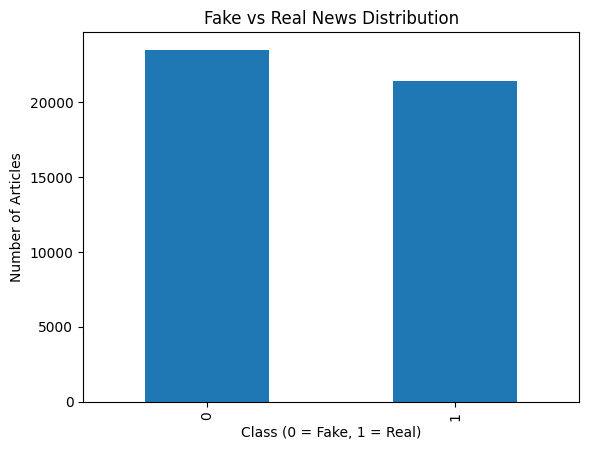

In [10]:
import matplotlib.pyplot as plt
plt.figure()

df['label'].value_counts().plot(kind='bar')

plt.title("Fake vs Real News Distribution")
plt.xlabel("Class (0 = Fake, 1 = Real)")
plt.ylabel("Number of Articles")

plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


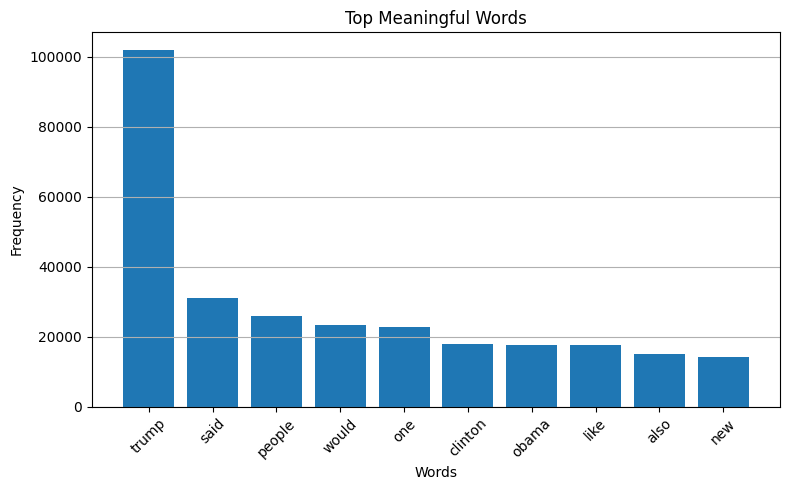

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

# Download once
nltk.download('stopwords')

# =========================
# STOPWORDS
# =========================
stop_words = set(stopwords.words('english'))

# =========================
# GET FAKE NEWS TEXT
# =========================
fake_text = " ".join(df[df['label'] == 0]['text'])

# =========================
# CLEAN TEXT
# =========================

# Lowercase
fake_text = fake_text.lower()

# Merge important names (VERY IMPORTANT)
fake_text = fake_text.replace("donald trump", "trump")
fake_text = fake_text.replace("trump's", "trump")

# Remove punctuation
fake_text = fake_text.translate(str.maketrans('', '', string.punctuation))

# Split words
words = fake_text.split()

# =========================
# REPLACE SIMILAR WORDS
# =========================
replace_dict = {
    "donald": "trump",
    "president": "trump"   # optional (can remove if you want)
}

words = [replace_dict.get(word, word) for word in words]

# =========================
# REMOVE STOPWORDS + SHORT WORDS
# =========================
filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

# =========================
# COUNT TOP WORDS
# =========================
common_words = Counter(filtered_words).most_common(10)

words, counts = zip(*common_words)

# =========================
# PLOT GRAPH
# =========================
plt.figure(figsize=(8,5))

plt.bar(words, counts)

plt.title("Top Meaningful Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numbers
vectorizer = TfidfVectorizer(max_df=0.7)

X = vectorizer.fit_transform(df['clean_text'])
y = df['label']
# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(
#     max_df=0.75,
#     min_df=3,
#     ngram_range=(1,2),
#     stop_words='english'
# )

X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

y_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 0.9394209354120268


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
# model = LogisticRegression(
#     max_iter=2000,
#     C=2.0,
#     solver='liblinear'
# )

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9856347438752784


In [17]:
from sklearn.svm import LinearSVC

# Create model
svm_model = LinearSVC()

# Train model
svm_model.fit(X_train, y_train)

# Predict
svm_pred = svm_model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9947661469933184


In [18]:
from sklearn.linear_model import PassiveAggressiveClassifier

# Create model
pac_model = PassiveAggressiveClassifier(max_iter=1000)

# Train model
pac_model.fit(X_train, y_train)

# Predict
pac_pred = pac_model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("Passive Aggressive Accuracy:", accuracy_score(y_test, pac_pred))

Passive Aggressive Accuracy: 0.9946547884187082


In [19]:
print("Logistic:", accuracy_score(y_test, y_pred))
print("Naive Bayes:", accuracy_score(y_test, nb_pred))
print("SVM:", accuracy_score(y_test, svm_pred))
print("Passive Aggressive:", accuracy_score(y_test, pac_pred))

Logistic: 0.9856347438752784
Naive Bayes: 0.9394209354120268
SVM: 0.9947661469933184
Passive Aggressive: 0.9946547884187082


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
vectorizer = TfidfVectorizer(max_df=0.7)

X = vectorizer.fit_transform(df['clean_text'])  # input features
y = df['label']                                 # output labels

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
vectorizer = TfidfVectorizer(
    max_df=0.7,
    min_df=5,
    ngram_range=(1,2)
)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # ensures same split every time
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(35918, 219160)
(8980, 219160)


In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
# model = LogisticRegression(
#     max_iter=2000,
#     C=2.0,
#     solver='liblinear'
# )

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9856347438752784


In [29]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9856347438752784


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4650
           1       0.98      0.99      0.99      4330

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4577   73]
 [  56 4274]]


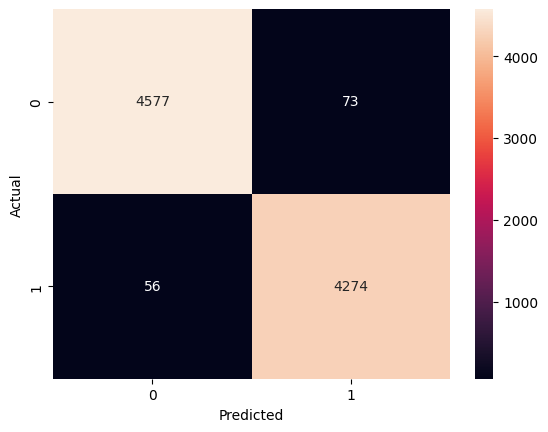

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

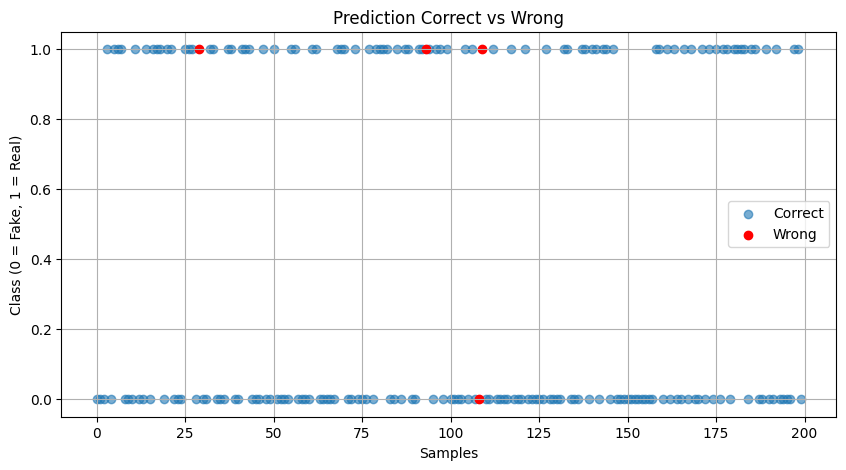

Total Samples: 200
Correct Predictions: 196
Wrong Predictions: 4
Accuracy: 0.98
Simple Loss: 0.020000000000000018
Log Loss: 0.09693329170932646


In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, log_loss

# Take subset
y_true = np.array(y_test[:200])
y_pred_list = np.array(y_pred[:200])

# If you have probability (for log loss)
try:
    y_prob = model.predict_proba(X_test[:200])[:,1]
    logloss = log_loss(y_true, y_prob)
except:
    logloss = None

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred_list)
loss = 1 - accuracy

# Count correct & wrong
correct = np.sum(y_true == y_pred_list)
wrong = np.sum(y_true != y_pred_list)

# X axis
x = np.arange(len(y_true))
errors = y_true != y_pred_list

# GRAPH
plt.figure(figsize=(10,5))

# Correct predictions
plt.scatter(x[~errors], y_true[~errors], label='Correct', alpha=0.6)

# Wrong predictions
plt.scatter(x[errors], y_pred_list[errors], color='red', label='Wrong')

plt.title("Prediction Correct vs Wrong")
plt.xlabel("Samples")
plt.ylabel("Class (0 = Fake, 1 = Real)")

plt.legend()
plt.grid()

plt.show()

print("Total Samples:", len(y_true))
print("Correct Predictions:", correct)
print("Wrong Predictions:", wrong)

print("Accuracy:", accuracy)
print("Simple Loss:", loss)

if logloss is not None:
    print("Log Loss:", logloss)

In [34]:
nb_acc = accuracy_score(y_test, nb_pred)
lr_acc = accuracy_score(y_test, y_pred)
svm_acc = accuracy_score(y_test, svm_pred)
pac_acc = accuracy_score(y_test, pac_pred)

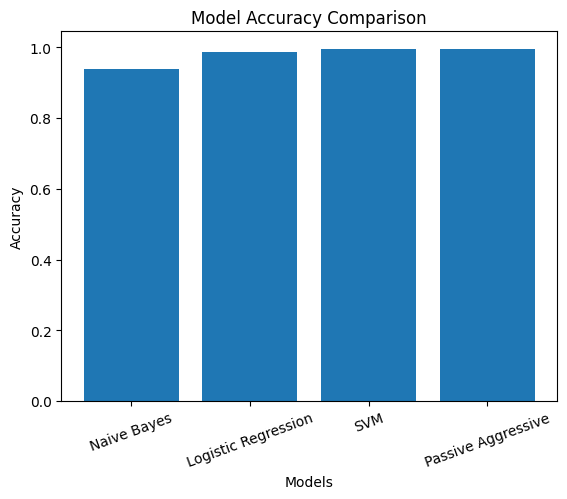

In [35]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression', 'SVM', 'Passive Aggressive']
accuracies = [nb_acc, lr_acc, svm_acc, pac_acc]

plt.figure()
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)
plt.show()

In [36]:
def predict_news():
    text = input("Enter news: ")

    # preprocess
    processed = preprocess_text(text)

    # convert to TF-IDF
    vector = vectorizer.transform([processed])

    # predict
    prediction = model.predict(vector)

    if prediction[0] == 0:
        print("🛑 Fake News")
    else:
        print("✅ Real News")



In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Re-initialize and fit the vectorizer that was used for model training.
# This ensures that predict_news uses a fitted vectorizer consistent with the model.
vectorizer = TfidfVectorizer(max_df=0.7)
vectorizer.fit(df['clean_text'])
# Run it
predict_news()

Enter news: Sources claim that the Supreme Court of India has passed a confidential order removing fundamental rights, which will be announced later.
🛑 Fake News
